In [1]:
# Gini index: [0,0.5]
# Information Gain:[0,1]
# CART: Classification and regression Tree
# Decision Tree pruning: used to avoid overfitting 

## Problem Statement: Identify either note is Genuine or not using predictive modelling  and with the help of Decision tree

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv('banknotes.csv')
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
# lets Create input and output data
X = df.drop(columns='Class')
X[:3]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210
2,3.8660,-2.6383,1.9242,0.10645


In [5]:
y = df['Class']
y[:3]

0    0
1    0
2    0
Name: Class, dtype: int64

In [6]:
# splitting the dataset
from sklearn.model_selection import train_test_split

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [8]:
# Import Descision tree algo
#from sklearn.tree import DecisionTreeRegressor

# current problem is binary classification problem
# hence classifier wil be used
from sklearn.tree import DecisionTreeClassifier

In [9]:
model = DecisionTreeClassifier()

In [10]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [11]:
model.classes_

array([0, 1], dtype=int64)

In [12]:
# prediction
y_pred = model.predict(X_test)
y_pred[:5]

array([0, 1, 0, 0, 1], dtype=int64)

In [13]:
y_test[:5]

187     0
1342    1
545     0
217     0
817     1
Name: Class, dtype: int64

In [14]:
# Lets check trianing data score
model.score(X_train,y_train)*100

100.0

In [15]:
model.score(X_test,y_test)*100

98.54545454545455

In [16]:
#performance metrics
from sklearn.metrics import confusion_matrix,classification_report

In [17]:
confusion_matrix(y_test,y_pred)

array([[149,   2],
       [  2, 122]], dtype=int64)

In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       151
           1       0.98      0.98      0.98       124

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [19]:
model.criterion

'gini'

In [20]:
# LEst apply entropy
model2 = DecisionTreeClassifier(criterion='entropy')

In [21]:
model2.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

In [22]:
y_pred2 = model2.predict(X_test)

In [23]:
confusion_matrix(y_test,y_pred2)

array([[151,   0],
       [  1, 123]], dtype=int64)

In [24]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       151
           1       1.00      0.99      1.00       124

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



# Cross Validation

In [34]:
from sklearn.model_selection import cross_val_score

In [35]:
cross_val_score?

In [36]:
model

DecisionTreeClassifier()

In [37]:
X[:4]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210
2,3.8660,-2.6383,1.9242,0.10645
3,3.4566,9.5228,-4.0112,-3.59440


In [38]:
y[:4]

0    0
1    0
2    0
3    0
Name: Class, dtype: int64

In [42]:
y.unique()

array([0, 1], dtype=int64)

In [39]:
X.shape

(1372, 4)

In [40]:
cv_score = cross_val_score(model,X,y)
#default cv value is =5
cv_score

array([0.98545455, 0.97090909, 0.98175182, 0.98540146, 0.98540146])

In [41]:
cv_score.mean()*100

98.17836761778368

In [44]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()

In [46]:
cv_3 = cross_val_score(LR,X,y,cv=3)
cv_3

array([0.98908297, 0.9868709 , 0.99343545])

In [47]:
cv_3.mean()

0.989796438388452

In [48]:
from sklearn.naive_bayes import GaussianNB

In [49]:
cross_val_score(GaussianNB(),X,y).mean()*100

83.82057067020571

## we have 2 options: 
# Stratified Kfold 
# Kfold cross validation

In [ ]:
[0,1,2,3,4,5,6,7]
Train: [1 2 3 5 6 7] | test: [0 4]
Train: [0 2 3 4 6 7] | test: [1 5]
Train: [0 1 3 4 5 7] | test: [2 6]
Train: [0 1 2 4 5 6] | test: [3 7]
StratifiedKFold done

Train: [2 3 4 5 6 7] | test: [0 1]
Train: [0 1 4 5 6 7] | test: [2 3]
Train: [0 1 2 3 6 7] | test: [4 5]
Train: [0 1 2 3 4 5] | test: [6 7]
KFold done

In [50]:
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

In [51]:
X = np.array([
    [1,2,3,4],
    [11,12,13,14],
    [21,22,23,24],
    [31,32,33,34],
    [41,42,43,44],
    [51,52,53,54],
    [61,62,63,64],
    [71,72,73,74]
])

y = np.array([0,0,0,0,1,1,1,1])

In [52]:
kf = KFold(n_splits=4)
# default  n_split=5

In [53]:
kf.split(X)

<generator object _BaseKFold.split at 0x000001A161FEB820>

In [54]:
list(kf.split(X))

[(array([2, 3, 4, 5, 6, 7]), array([0, 1])),
 (array([0, 1, 4, 5, 6, 7]), array([2, 3])),
 (array([0, 1, 2, 3, 6, 7]), array([4, 5])),
 (array([0, 1, 2, 3, 4, 5]), array([6, 7]))]

In [55]:
skf = StratifiedKFold(n_splits=4)
skf

StratifiedKFold(n_splits=4, random_state=None, shuffle=False)

In [57]:
skf.split(X,y)

<generator object _BaseKFold.split at 0x000001A161E2E120>

In [58]:
list(skf.split(X,y))
#[array(training_index),array(test_index)]

[(array([1, 2, 3, 5, 6, 7]), array([0, 4])),
 (array([0, 2, 3, 4, 6, 7]), array([1, 5])),
 (array([0, 1, 3, 4, 5, 7]), array([2, 6])),
 (array([0, 1, 2, 4, 5, 6]), array([3, 7]))]

In [59]:
for train_index,test_index in skf.split(X,y):
    print(train_index,test_index)

[1 2 3 5 6 7] [0 4]
[0 2 3 4 6 7] [1 5]
[0 1 3 4 5 7] [2 6]
[0 1 2 4 5 6] [3 7]


In [61]:
for train_index,test_index in skf.split(X,y):
    print(X[train_index],X[test_index])# X_train,X_test

[[11 12 13 14]
 [21 22 23 24]
 [31 32 33 34]
 [51 52 53 54]
 [61 62 63 64]
 [71 72 73 74]] [[ 1  2  3  4]
 [41 42 43 44]]
[[ 1  2  3  4]
 [21 22 23 24]
 [31 32 33 34]
 [41 42 43 44]
 [61 62 63 64]
 [71 72 73 74]] [[11 12 13 14]
 [51 52 53 54]]
[[ 1  2  3  4]
 [11 12 13 14]
 [31 32 33 34]
 [41 42 43 44]
 [51 52 53 54]
 [71 72 73 74]] [[21 22 23 24]
 [61 62 63 64]]
[[ 1  2  3  4]
 [11 12 13 14]
 [21 22 23 24]
 [41 42 43 44]
 [51 52 53 54]
 [61 62 63 64]] [[31 32 33 34]
 [71 72 73 74]]


In [60]:
X

array([[ 1,  2,  3,  4],
       [11, 12, 13, 14],
       [21, 22, 23, 24],
       [31, 32, 33, 34],
       [41, 42, 43, 44],
       [51, 52, 53, 54],
       [61, 62, 63, 64],
       [71, 72, 73, 74]])

# DT visualization

In [25]:
from sklearn import tree

In [26]:
X = df.iloc[:,:-1]
X[:2]

,Variance,Skewness,Curtosis,Entropy
0,3.6216,8.6661,-2.8073,-0.44699
1,4.5459,8.1674,-2.4586,-1.46210


In [28]:
X.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy'], dtype='object')

In [27]:
model

DecisionTreeClassifier()

In [29]:
text_representation = tree.export_text(model,feature_names=['Variance', 'Skewness', 'Curtosis', 'Entropy'])
print(text_representation)

|--- Variance <= 0.32
|   |--- Skewness <= 5.87
|   |   |--- Curtosis <= 6.75
|   |   |   |--- Curtosis <= 3.06
|   |   |   |   |--- class: 1
|   |   |   |--- Curtosis >  3.06
|   |   |   |   |--- Skewness <= -0.48
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Skewness >  -0.48
|   |   |   |   |   |--- class: 0
|   |   |--- Curtosis >  6.75
|   |   |   |--- Skewness <= -4.80
|   |   |   |   |--- Variance <= -0.53
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Variance >  -0.53
|   |   |   |   |   |--- class: 0
|   |   |   |--- Skewness >  -4.80
|   |   |   |   |--- class: 0
|   |--- Skewness >  5.87
|   |   |--- Variance <= -3.44
|   |   |   |--- Curtosis <= 2.11
|   |   |   |   |--- class: 1
|   |   |   |--- Curtosis >  2.11
|   |   |   |   |--- class: 0
|   |   |--- Variance >  -3.44
|   |   |   |--- class: 0
|--- Variance >  0.32
|   |--- Curtosis <= -4.39
|   |   |--- Variance <= 3.92
|   |   |   |--- class: 1
|   |   |--- Variance >  3.92
|   |   |   |--- class: 0

In [30]:
import matplotlib.pyplot as plt

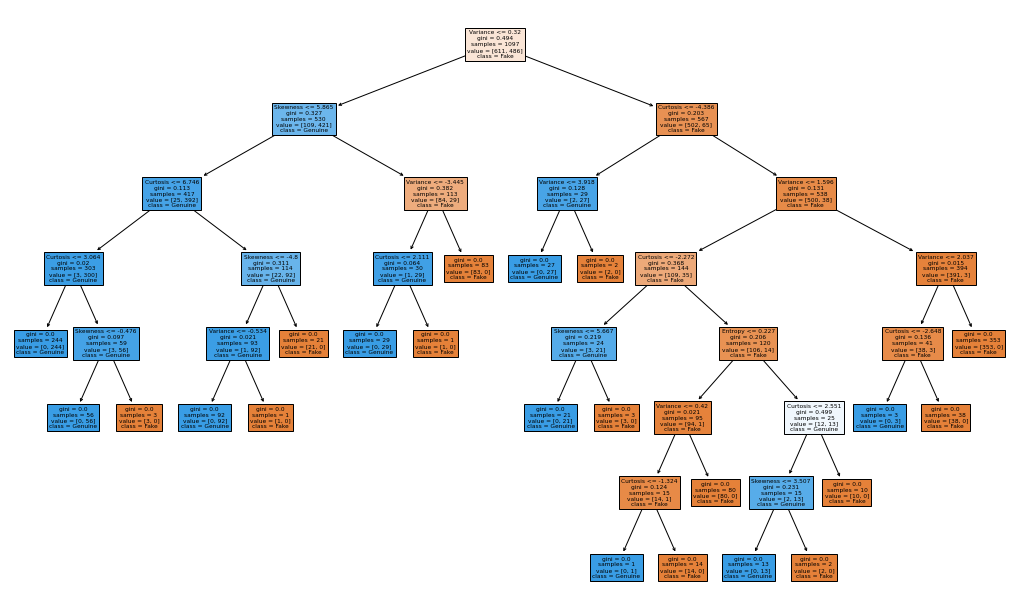

In [33]:
fig = plt.figure(figsize=(18,11))
_ = tree.plot_tree(model, 
                   feature_names=['Variance', 'Skewness', 'Curtosis', 'Entropy'],  
                   class_names=['Fake','Genuine'],
                   filled=True)
plt.savefig('sample_19.png',dpi=80)

In [ ]:
plt.figure(figsize=(12,12))
tree.plot_tree(model, fontsize=6)
plt.savefig('tree_high_dpi', dpi=100)

# Hyperparameter using GridSearch CV

In [ ]:
DecisionTreeClassifier()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
pr_grid = {
    'criterion':['gini','entropy'],
    'splitter':['best','random'],
    'max_depth':[2,3,4,5,6,8],
    'min_samples_split':[2,3],
    'min_samples_leaf':[1,2],
    'min_weight_fraction_leaf':[0.0,0.5]
    } 

In [ ]:
pr_grid

In [ ]:
"""
GridSearchCV(
    estimator,
    param_grid,
"""
out = GridSearchCV(DecisionTreeClassifier(),pr_grid)

In [ ]:
X[:2]

In [ ]:
y = df.Class
y[:2]

In [ ]:
out.fit(X,y)

In [ ]:
out.best_params_

In [ ]:
pr_grid

In [ ]:
out.best_estimator_

In [ ]:
final = DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_split=3)

In [ ]:
final.fit(X,y)

In [ ]:
final.score(X,y)*100

## Module Interface : 
 

- dumps() – This function is called to serialize an object hierarchy.
- loads() – This function is called to de-serialize a data stream.

# Serialization

In [ ]:
import pickle

In [ ]:
# save the DT_model to disk
filename = 'DT.pickle'
pickle.dump(final, open(filename, 'wb'))

# De Serialization

In [ ]:
# end user/testing  team/ client/ devops team will use pickled file
check = pickle.load(open('DT.h5','rb'))
check

In [ ]:
s = 'python'
k = ''
for i in s:
    k = i + k
print(k)

In [ ]:
s #-1,-2,-3,..-6

In [ ]:
for i in range(-1,- (len(s)+1),-1):
    print(s[i],end='')

In [ ]:
*
**
***
****
*****

In [ ]:
[print(i*'*') for i in range(1,6)]